# 🌸 Iris Flower Classification — Complete ML Pipeline
**Model:** Random Forest Classifier  
**Dataset:** Iris (150 samples, 3 classes, 4 features)

## 1. Imports

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 2. Load Dataset

In [2]:
csv_data = """Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
6,5.4,3.9,1.7,0.4,Iris-setosa
7,4.6,3.4,1.4,0.3,Iris-setosa
8,5.0,3.4,1.5,0.2,Iris-setosa
9,4.4,2.9,1.4,0.2,Iris-setosa
10,4.9,3.1,1.5,0.1,Iris-setosa
11,5.4,3.7,1.5,0.2,Iris-setosa
12,4.8,3.4,1.6,0.2,Iris-setosa
13,4.8,3.0,1.4,0.1,Iris-setosa
14,4.3,3.0,1.1,0.1,Iris-setosa
15,5.8,4.0,1.2,0.2,Iris-setosa
16,5.7,4.4,1.5,0.4,Iris-setosa
17,5.4,3.9,1.3,0.4,Iris-setosa
18,5.1,3.5,1.4,0.3,Iris-setosa
19,5.7,3.8,1.7,0.3,Iris-setosa
20,5.1,3.8,1.5,0.3,Iris-setosa
21,5.4,3.4,1.7,0.2,Iris-setosa
22,5.1,3.7,1.5,0.4,Iris-setosa
23,4.6,3.6,1.0,0.2,Iris-setosa
24,5.1,3.3,1.7,0.5,Iris-setosa
25,4.8,3.4,1.9,0.2,Iris-setosa
26,5.0,3.0,1.6,0.2,Iris-setosa
27,5.0,3.4,1.6,0.4,Iris-setosa
28,5.2,3.5,1.5,0.2,Iris-setosa
29,5.2,3.4,1.4,0.2,Iris-setosa
30,4.7,3.2,1.6,0.2,Iris-setosa
31,4.8,3.1,1.6,0.2,Iris-setosa
32,5.4,3.4,1.5,0.4,Iris-setosa
33,5.2,4.1,1.5,0.1,Iris-setosa
34,5.5,4.2,1.4,0.2,Iris-setosa
35,4.9,3.1,1.5,0.1,Iris-setosa
36,5.0,3.2,1.2,0.2,Iris-setosa
37,5.5,3.5,1.3,0.2,Iris-setosa
38,4.9,3.1,1.5,0.1,Iris-setosa
39,4.4,3.0,1.3,0.2,Iris-setosa
40,5.1,3.4,1.5,0.2,Iris-setosa
41,5.0,3.5,1.3,0.3,Iris-setosa
42,4.5,2.3,1.3,0.3,Iris-setosa
43,4.4,3.2,1.3,0.2,Iris-setosa
44,5.0,3.5,1.6,0.6,Iris-setosa
45,5.1,3.8,1.9,0.4,Iris-setosa
46,4.8,3.0,1.4,0.3,Iris-setosa
47,5.1,3.8,1.6,0.2,Iris-setosa
48,4.6,3.2,1.4,0.2,Iris-setosa
49,5.3,3.7,1.5,0.2,Iris-setosa
50,5.0,3.3,1.4,0.2,Iris-setosa
51,7.0,3.2,4.7,1.4,Iris-versicolor
52,6.4,3.2,4.5,1.5,Iris-versicolor
53,6.9,3.1,4.9,1.5,Iris-versicolor
54,5.5,2.3,4.0,1.3,Iris-versicolor
55,6.5,2.8,4.6,1.5,Iris-versicolor
56,5.7,2.8,4.5,1.3,Iris-versicolor
57,6.3,3.3,4.7,1.6,Iris-versicolor
58,4.9,2.4,3.3,1.0,Iris-versicolor
59,6.6,2.9,4.6,1.3,Iris-versicolor
60,5.2,2.7,3.9,1.4,Iris-versicolor
61,5.0,2.0,3.5,1.0,Iris-versicolor
62,5.9,3.0,4.2,1.5,Iris-versicolor
63,6.0,2.2,4.0,1.0,Iris-versicolor
64,6.1,2.9,4.7,1.4,Iris-versicolor
65,5.6,2.9,3.6,1.3,Iris-versicolor
66,6.7,3.1,4.4,1.4,Iris-versicolor
67,5.6,3.0,4.5,1.5,Iris-versicolor
68,5.8,2.7,4.1,1.0,Iris-versicolor
69,6.2,2.2,4.5,1.5,Iris-versicolor
70,5.6,2.5,3.9,1.1,Iris-versicolor
71,5.9,3.2,4.8,1.8,Iris-versicolor
72,6.1,2.8,4.0,1.3,Iris-versicolor
73,6.3,2.5,4.9,1.5,Iris-versicolor
74,6.1,2.8,4.7,1.2,Iris-versicolor
75,6.4,2.9,4.3,1.3,Iris-versicolor
76,6.6,3.0,4.4,1.4,Iris-versicolor
77,6.8,2.8,4.8,1.4,Iris-versicolor
78,6.7,3.0,5.0,1.7,Iris-versicolor
79,6.0,2.9,4.5,1.5,Iris-versicolor
80,5.7,2.6,3.5,1.0,Iris-versicolor
81,5.5,2.4,3.8,1.1,Iris-versicolor
82,5.5,2.4,3.7,1.0,Iris-versicolor
83,5.8,2.7,3.9,1.2,Iris-versicolor
84,6.0,2.7,5.1,1.6,Iris-versicolor
85,5.4,3.0,4.5,1.5,Iris-versicolor
86,6.0,3.4,4.5,1.6,Iris-versicolor
87,6.7,3.1,4.7,1.5,Iris-versicolor
88,6.3,2.3,4.4,1.3,Iris-versicolor
89,5.6,3.0,4.1,1.3,Iris-versicolor
90,5.5,2.5,4.0,1.3,Iris-versicolor
91,5.5,2.6,4.4,1.2,Iris-versicolor
92,6.1,3.0,4.6,1.4,Iris-versicolor
93,5.8,2.6,4.0,1.2,Iris-versicolor
94,5.0,2.3,3.3,1.0,Iris-versicolor
95,5.6,2.7,4.2,1.3,Iris-versicolor
96,5.7,3.0,4.2,1.2,Iris-versicolor
97,5.7,2.9,4.2,1.3,Iris-versicolor
98,6.2,2.9,4.3,1.3,Iris-versicolor
99,5.1,2.5,3.0,1.1,Iris-versicolor
100,5.7,2.8,4.1,1.3,Iris-versicolor
101,6.3,3.3,6.0,2.5,Iris-virginica
102,5.8,2.7,5.1,1.9,Iris-virginica
103,7.1,3.0,5.9,2.1,Iris-virginica
104,6.3,2.9,5.6,1.8,Iris-virginica
105,6.5,3.0,5.8,2.2,Iris-virginica
106,7.6,3.0,6.6,2.1,Iris-virginica
107,4.9,2.5,4.5,1.7,Iris-virginica
108,7.3,2.9,6.3,1.8,Iris-virginica
109,6.7,2.5,5.8,1.8,Iris-virginica
110,7.2,3.6,6.1,2.5,Iris-virginica
111,6.5,3.2,5.1,2.0,Iris-virginica
112,6.4,2.7,5.3,1.9,Iris-virginica
113,6.8,3.0,5.5,2.1,Iris-virginica
114,5.7,2.5,5.0,2.0,Iris-virginica
115,5.8,2.8,5.1,2.4,Iris-virginica
116,6.4,3.2,5.3,2.3,Iris-virginica
117,6.5,3.0,5.5,1.8,Iris-virginica
118,7.7,3.8,6.7,2.2,Iris-virginica
119,7.7,2.6,6.9,2.3,Iris-virginica
120,6.0,2.2,5.0,1.5,Iris-virginica
121,6.9,3.2,5.7,2.3,Iris-virginica
122,5.6,2.8,4.9,2.0,Iris-virginica
123,7.7,2.8,6.7,2.0,Iris-virginica
124,6.3,2.7,4.9,1.8,Iris-virginica
125,6.7,3.3,5.7,2.1,Iris-virginica
126,7.2,3.2,6.0,1.8,Iris-virginica
127,6.2,2.8,4.8,1.8,Iris-virginica
128,6.1,3.0,4.9,1.8,Iris-virginica
129,6.4,2.8,5.6,2.1,Iris-virginica
130,7.2,3.0,5.8,1.6,Iris-virginica
131,7.4,2.8,6.1,1.9,Iris-virginica
132,7.9,3.8,6.4,2.0,Iris-virginica
133,6.4,2.8,5.6,2.2,Iris-virginica
134,6.3,2.8,5.1,1.5,Iris-virginica
135,6.1,2.6,5.6,1.4,Iris-virginica
136,7.7,3.0,6.1,2.3,Iris-virginica
137,6.3,3.4,5.6,2.4,Iris-virginica
138,6.4,3.1,5.5,1.8,Iris-virginica
139,6.0,3.0,4.8,1.8,Iris-virginica
140,6.9,3.1,5.4,2.1,Iris-virginica
141,6.7,3.1,5.6,2.4,Iris-virginica
142,6.9,3.1,5.1,2.3,Iris-virginica
143,5.8,2.7,5.1,1.9,Iris-virginica
144,6.8,3.2,5.9,2.3,Iris-virginica
145,6.7,3.3,5.7,2.5,Iris-virginica
146,6.7,3.0,5.2,2.3,Iris-virginica
147,6.3,2.5,5.0,1.9,Iris-virginica
148,6.5,3.0,5.2,2.0,Iris-virginica
149,6.2,3.4,5.4,2.3,Iris-virginica
150,5.9,3.0,5.1,1.8,Iris-virginica"""

df = pd.read_csv(io.StringIO(csv_data))
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Class Distribution ===")
print(df['Species'].value_counts())

print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None

=== Missing Values ===
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

=== Class Distribution ===
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

=== Statistical Summary ===


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


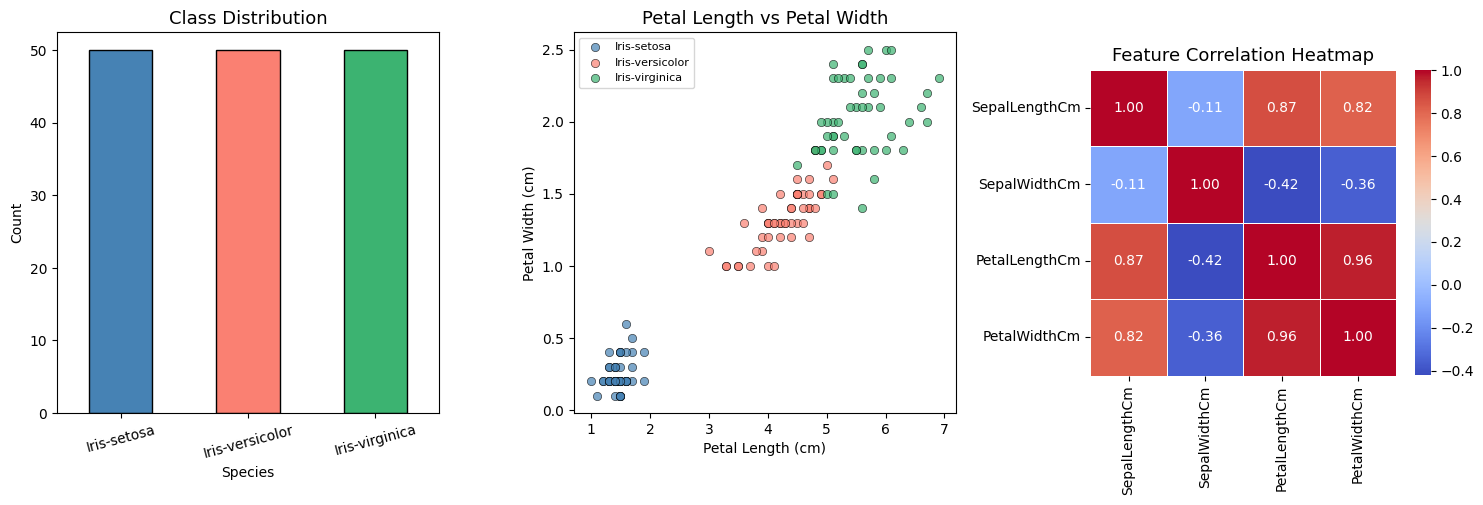

EDA plots saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Class Distribution
df['Species'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon', 'mediumseagreen'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# 2. Pairplot features (Petal Length vs Petal Width)
colors = {'Iris-setosa': 'steelblue', 'Iris-versicolor': 'salmon', 'Iris-virginica': 'mediumseagreen'}
for species, color in colors.items():
    subset = df[df['Species'] == species]
    axes[1].scatter(subset['PetalLengthCm'], subset['PetalWidthCm'],
                    label=species, alpha=0.7, color=color, edgecolors='black', linewidths=0.5)
axes[1].set_title('Petal Length vs Petal Width', fontsize=13)
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend(fontsize=8)

# 3. Feature Correlation Heatmap
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2],
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
axes[2].set_title('Feature Correlation Heatmap', fontsize=13)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved.")

## 4. Data Preparation

In [5]:
# Drop Id, split features and target
X = df.drop(columns=['Id', 'Species'])
y = df['Species']

# Stratified split — ensures each class is proportionally represented
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Test set size     : {X_test.shape[0]} samples")
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

Training set size : 120 samples
Test set size     : 30 samples

Class distribution in training set:
Species
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64

Class distribution in test set:
Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


## 5. Cross-Validation (Baseline)

In [6]:
baseline_model = RandomForestClassifier(random_state=SEED)

# 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(baseline_model, X, y, cv=skf, scoring='accuracy')

print("=== 5-Fold Cross-Validation (Baseline) ===")
print(f"Fold Scores : {[round(s, 4) for s in cv_scores]}")
print(f"Mean        : {cv_scores.mean():.4f}")
print(f"Std Dev     : {cv_scores.std():.4f}")
print(f"95% CI      : [{cv_scores.mean() - 2*cv_scores.std():.4f}, {cv_scores.mean() + 2*cv_scores.std():.4f}]")

=== 5-Fold Cross-Validation (Baseline) ===
Fold Scores : [np.float64(0.9667), np.float64(0.9667), np.float64(0.9333), np.float64(0.9667), np.float64(0.9)]
Mean        : 0.9467
Std Dev     : 0.0267
95% CI      : [0.8933, 1.0000]


## 6. Hyperparameter Tuning (GridSearchCV)

In [7]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print("=== Best Hyperparameters ===")
print(grid_search.best_params_)
print(f"\nBest CV Accuracy: {grid_search.best_score_:.4f}")

=== Best Hyperparameters ===
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}

Best CV Accuracy: 0.9667


## 7. Final Model Evaluation

In [8]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("=" * 45)
print("         FINAL MODEL EVALUATION")
print("=" * 45)
print(f"Test Set Accuracy : {accuracy * 100:.2f}%")
print(f"CV Mean Accuracy  : {cv_scores.mean() * 100:.2f}% ± {cv_scores.std() * 100:.2f}%")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

         FINAL MODEL EVALUATION
Test Set Accuracy : 96.67%
CV Mean Accuracy  : 94.67% ± 2.67%

--- Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



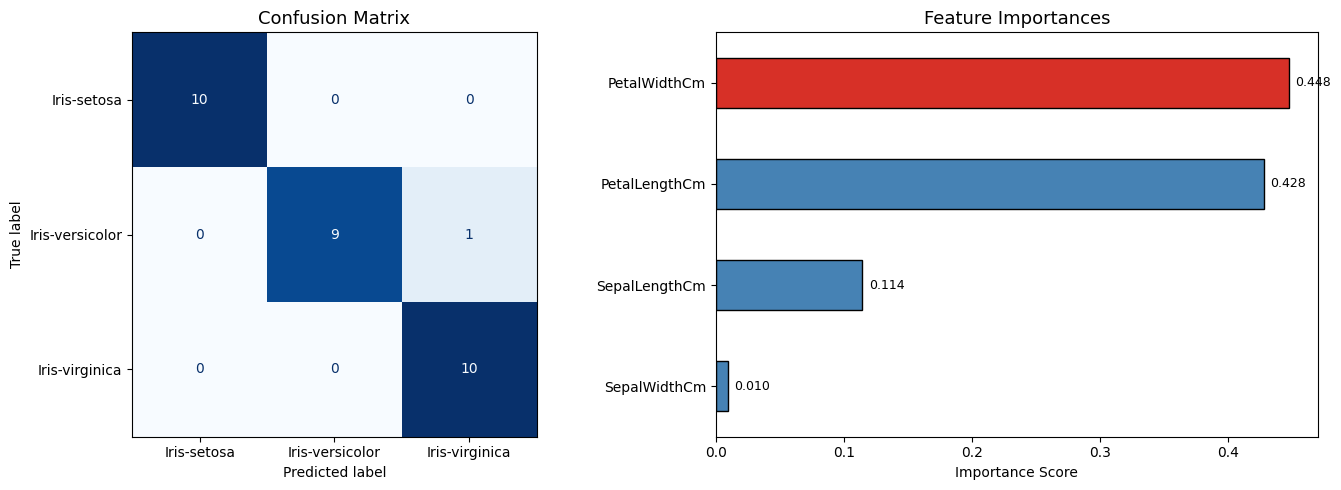

Results plots saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=13)

# 2. Feature Importances
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
colors_fi = ['#d73027' if i == importances.index[-1] else 'steelblue' for i in importances.index]
importances.plot(kind='barh', ax=axes[1], color=colors_fi, edgecolor='black')
axes[1].set_title('Feature Importances', fontsize=13)
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(importances):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results plots saved.")

## 8. Feature Importance Summary

In [10]:
fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fi_df['Rank'] = fi_df.index + 1
print(fi_df[['Rank', 'Feature', 'Importance']].to_string(index=False))

 Rank       Feature  Importance
    1  PetalWidthCm    0.447731
    2 PetalLengthCm    0.428163
    3 SepalLengthCm    0.114441
    4  SepalWidthCm    0.009665


## 9. Predict on New Data

In [11]:
# Example: predict species for new flower measurements
new_samples = pd.DataFrame({
    'SepalLengthCm': [5.1, 6.5, 7.2],
    'SepalWidthCm':  [3.5, 2.8, 3.0],
    'PetalLengthCm': [1.4, 4.6, 5.8],
    'PetalWidthCm':  [0.2, 1.5, 2.1]
})

predictions = best_model.predict(new_samples)
probabilities = best_model.predict_proba(new_samples)

print("=== Predictions on New Samples ===")
for i, (pred, probs) in enumerate(zip(predictions, probabilities)):
    confidence = max(probs) * 100
    print(f"Sample {i+1}: {pred:<20} | Confidence: {confidence:.1f}%")

=== Predictions on New Samples ===
Sample 1: Iris-setosa          | Confidence: 100.0%
Sample 2: Iris-versicolor      | Confidence: 96.7%
Sample 3: Iris-virginica       | Confidence: 100.0%


## 10. Pipeline Summary

| Step | Detail |
|------|--------|
| Dataset | 150 samples, 3 classes, 4 features |
| Split | 80/20 stratified train/test |
| Validation | 5-Fold Stratified Cross-Validation |
| Tuning | GridSearchCV over 36 hyperparameter combinations |
| Model | RandomForestClassifier (best params) |
| Key Finding | PetalLengthCm & PetalWidthCm are the most predictive features |